# Car Price Prediction Using Machine Learning

## Introduction

In this project, we will analyze car data and build a machine learning
model to predict the selling price of a used car.

We will first understand and clean the data, then perform some data
analysis and visualization.

After that, we will train regression models and compare their results.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In this step, we will load the car dataset using pandas and store it in a
DataFrame for further analysis.

In [3]:
df=pd.read_csv("car_data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Checking the Dataset Size

Here, we will check the number of rows and columns in the dataset.

In [5]:
df.shape

(301, 9)

## Checking the Column Names

In this step, we will check the names of all the columns available in
the dataset.

In [6]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

## Checking Dataset Information

Here, we will check the data types, number of non-null values, and
overall information about the dataset.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## Checking Data Types

We will check the data type of each column to understand which columns
contain numerical data and which contain categorical data.

In [8]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

## Checking Missing Values

In this step, we will check whether the dataset contains any missing
values in the columns.

In [9]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## Statistical Summary

Here, we will look at the basic statistical summary of the numerical
columns, such as the mean, minimum, maximum, and quartile values.

In [10]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Initial Data Understanding

The dataset contains 301 rows and 9 columns.

There are no missing values in the dataset.

The dataset contains both numerical and categorical columns.

The numerical columns are Year, Selling_Price, Present_Price, Kms_Driven,
and Owner.

The categorical columns are Car_Name, Fuel_Type, Seller_Type, and
Transmission.

Selling_Price will be used as the target variable for predicting the
price of a used car.

## Exploring Categorical Columns

In this step, we will check the unique values and value counts of the
categorical columns in the dataset.

In [11]:
categorical_columns = ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]

for column in categorical_columns:
    print("Column:", column)
    print("Unique values:", df[column].unique())
    print("Value counts:")
    print(df[column].value_counts())
    print("-" * 40)

Column: Fuel_Type
Unique values: ['Petrol' 'Diesel' 'CNG']
Value counts:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
----------------------------------------
Column: Seller_Type
Unique values: ['Dealer' 'Individual']
Value counts:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
----------------------------------------
Column: Transmission
Unique values: ['Manual' 'Automatic']
Value counts:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64
----------------------------------------
Column: Owner
Unique values: [0 1 3]
Value counts:
Owner
0    290
1     10
3      1
Name: count, dtype: int64
----------------------------------------


## Checking Duplicate Rows

Here, we will check whether the dataset contains any duplicate rows.
Duplicate rows can affect the result of a machine learning model.

In [12]:
df.duplicated().sum()

np.int64(2)

## Duplicate Rows Result

The duplicate row count is checked to understand whether any repeated
records are present in the dataset.

In [13]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (299, 9)


## Exploring Numerical Columns

In this step, we will check the minimum, maximum, average, and other
statistical values of the numerical columns.

In [14]:
numerical_columns = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner"
]

df[numerical_columns].describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Creating Car Age

The dataset contains the manufacturing year of each car.

We will create a new column called Car_Age by subtracting the car year
from the current year.

In [15]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]

df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


## Checking Car Age Values

Here, we will check the basic statistics of the newly created Car_Age
column.

In [16]:
df["Car_Age"].describe()

count    299.000000
mean      12.384615
std        2.896868
min        8.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       23.000000
Name: Car_Age, dtype: float64

## Selling Price Distribution

In this step, we will plot the distribution of selling prices.

This helps us understand how the selling prices are spread across the
dataset.

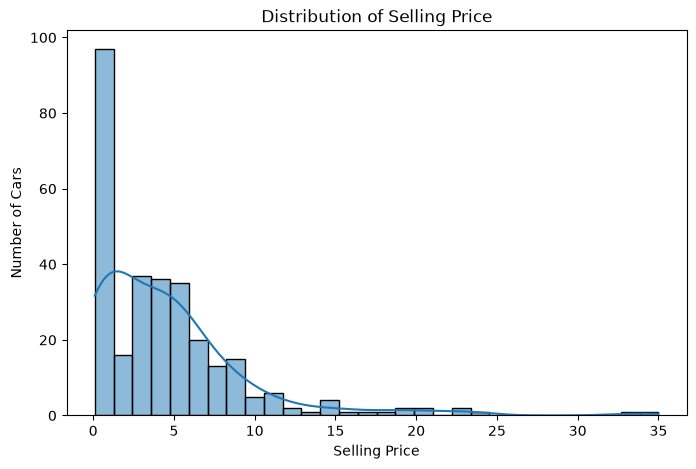

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

## Present Price Distribution

Here, we will plot the distribution of the present price of cars.

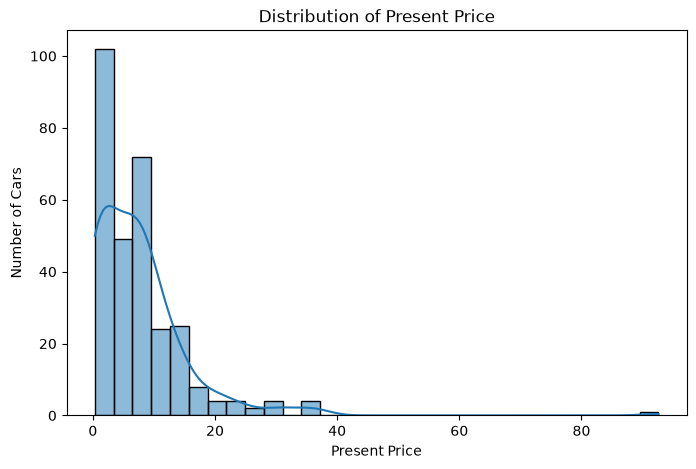

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Present_Price"], bins=30, kde=True)

plt.title("Distribution of Present Price")
plt.xlabel("Present Price")
plt.ylabel("Number of Cars")
plt.show()

## Car Age and Selling Price

In this step, we will check the relationship between car age and selling
price using a scatter plot.

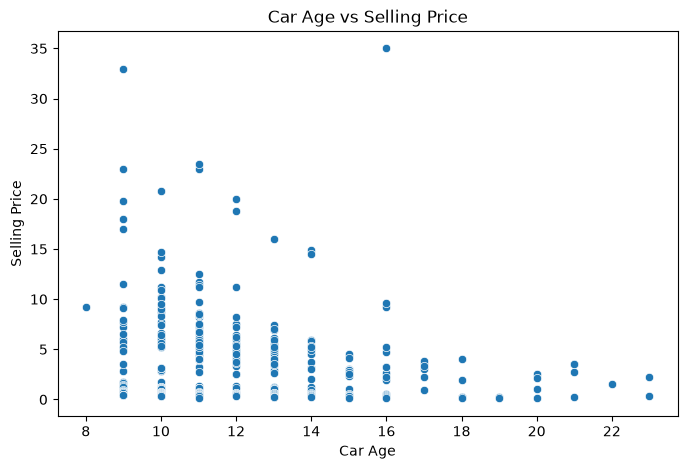

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

## Present Price and Selling Price

Here, we will check the relationship between present price and selling
price.

This can help us understand whether expensive cars generally have higher
selling prices.

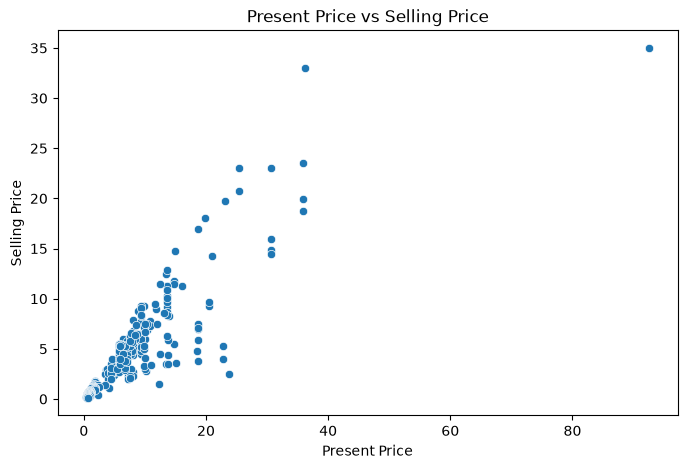

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

## Kilometers Driven and Selling Price

In this step, we will check the relationship between the distance driven
by the car and its selling price.

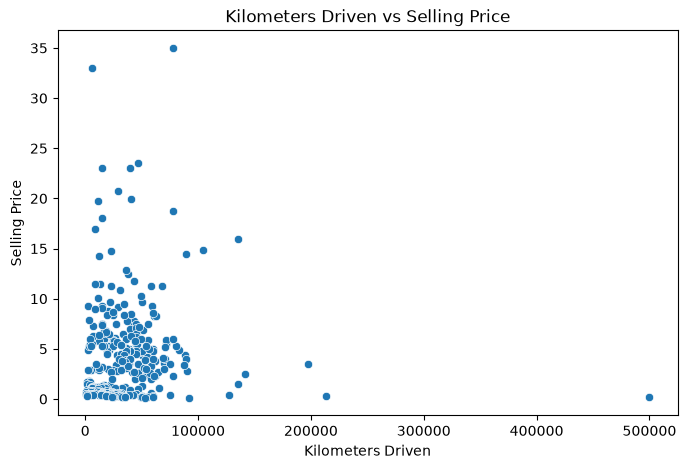

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

## Fuel Type and Selling Price

Here, we will compare the selling prices of cars based on their fuel type.

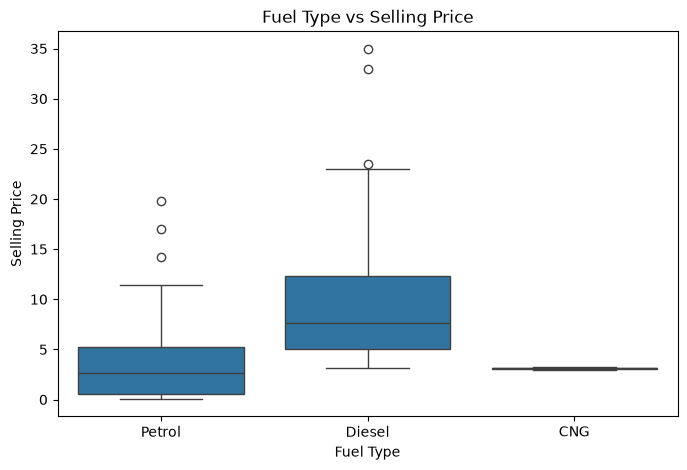

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Fuel Type vs Selling Price")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

## Seller Type and Selling Price

In this step, we will compare the selling prices of cars sold by dealers
and individual sellers.

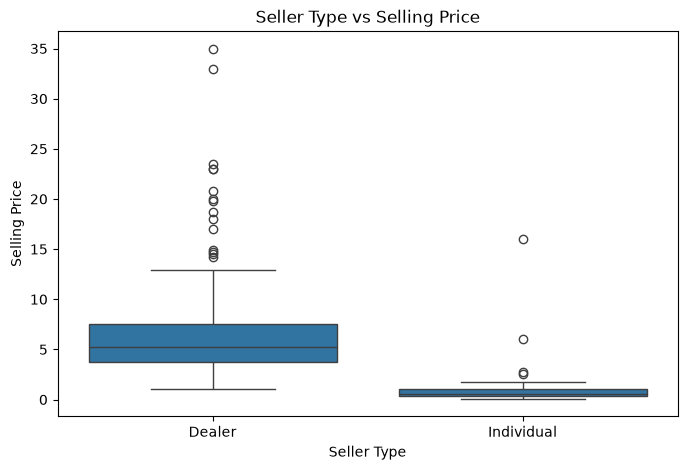

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Seller_Type",
    y="Selling_Price"
)

plt.title("Seller Type vs Selling Price")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")
plt.show()

## Correlation Analysis

In this step, we will check the correlation between the numerical columns.

Correlation helps us understand how strongly two numerical variables are
related to each other.

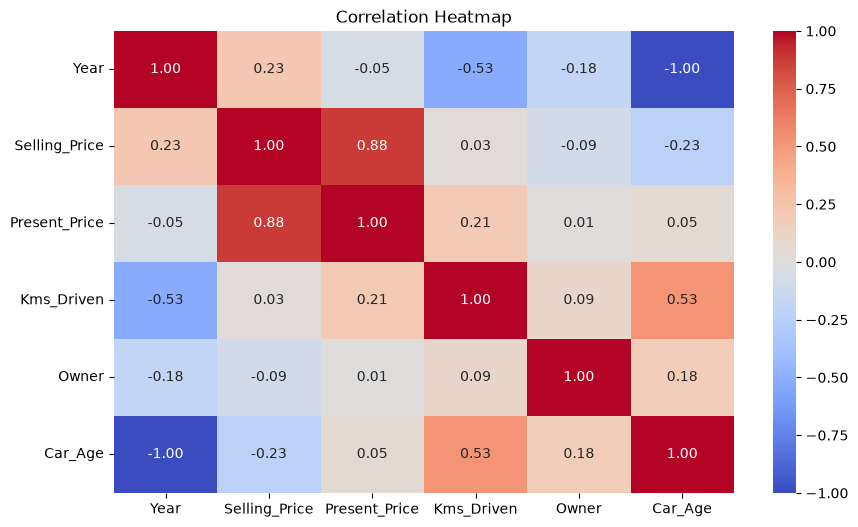

In [24]:
plt.figure(figsize=(10, 6))

correlation = df[
    ["Year", "Selling_Price", "Present_Price", "Kms_Driven", "Owner", "Car_Age"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Selecting Features and Target

The target variable is Selling_Price because we want to predict the
selling price of a used car.

The remaining useful columns will be used as input features.

In [25]:
X = df[
    [
        "Present_Price",
        "Kms_Driven",
        "Fuel_Type",
        "Seller_Type",
        "Transmission",
        "Owner",
        "Car_Age"
    ]
]

y = df["Selling_Price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (299, 7)
Target shape: (299,)


## Encoding Categorical Columns

Machine learning models work with numerical values.

Therefore, we will convert the categorical columns into numerical values
using one-hot encoding.

In [26]:
X = pd.get_dummies(
    X,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True
)

X.head()

,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000,0,12,False,True,False,True
1,9.54,43000,0,13,True,False,False,True
2,9.85,6900,0,9,False,True,False,True
3,4.15,5200,0,15,False,True,False,True
4,6.87,42450,0,12,True,False,False,True


## Checking Encoded Features

Here, we will check the column names after converting the categorical
columns into numerical values.

In [27]:
print("Feature columns:")
print(X.columns)

print("\nFeature shape:", X.shape)

Feature columns:
Index(['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual'],
      dtype='object')

Feature shape: (299, 8)


## Converting Features to Numeric Type

In this step, we will make sure that all feature columns contain numerical
values that can be used by machine learning models.

In [28]:
X = X.astype(float)

X.dtypes

Present_Price             float64
Kms_Driven                float64
Owner                     float64
Car_Age                   float64
Fuel_Type_Diesel          float64
Fuel_Type_Petrol          float64
Seller_Type_Individual    float64
Transmission_Manual       float64
dtype: object

## Splitting the Dataset

We will divide the dataset into training and testing parts.

The training data will be used to train the models.

The testing data will be used to check how well the models predict new
data.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (239, 8)
Testing features: (60, 8)
Training target: (239,)
Testing target: (60,)


## Feature Scaling

Some numerical features have different ranges.

We will use StandardScaler to scale the features before training the
Linear Regression model.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training Linear Regression Model

Linear Regression is a regression algorithm used to predict numerical
values.

We will train the model using the training data.

In [33]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_predictions = linear_model.predict(X_test_scaled)

linear_predictions[:10]

array([ 7.50192151,  7.79152142,  1.36644388,  7.00941894, 11.16328988,
        4.53410247,  8.49246345,  1.70078181,  8.82421963, -0.96348801])

## Evaluating Linear Regression

We will evaluate the Linear Regression model using Mean Absolute Error,
Root Mean Squared Error, and R-squared score.

Lower MAE and RMSE values are better.

A higher R-squared score means better model performance.

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Results
MAE: 1.4728924140032913
RMSE: 2.524035054594773
R2 Score: 0.7528154215832931


## Training Decision Tree Regressor

Decision Tree Regressor is a machine learning algorithm that predicts
numerical values by splitting the data into different groups.

We will train a Decision Tree model and compare its performance with
Linear Regression.

In [35]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=8
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

decision_tree_predictions[:10]

array([ 9.83666667,  7.21428571,  0.433     ,  7.21428571, 14.5       ,
        5.52142857,  5.9       ,  1.13125   ,  7.575     ,  0.175     ])

## Evaluating Decision Tree Regressor

Here, we will calculate the MAE, RMSE, and R-squared score for the
Decision Tree model.

In [36]:
tree_mae = mean_absolute_error(
    y_test,
    decision_tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, decision_tree_predictions)
)

tree_r2 = r2_score(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Results")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R2 Score:", tree_r2)

Decision Tree Results
MAE: 1.3611740079365078
RMSE: 3.1710433465962797
R2 Score: 0.6098469871880453


## Training Random Forest Regressor

Random Forest is an ensemble machine learning algorithm that combines
multiple decision trees.

It can provide better prediction results than a single decision tree.

In [37]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

random_forest_predictions[:10]

array([ 9.52623006,  8.18753045,  0.43817894,  6.95977888, 19.4112    ,
        5.30328651,  6.88468333,  1.17671813,  7.88051973,  0.31559813])

## Evaluating Random Forest Regressor

In this step, we will calculate the MAE, RMSE, and R-squared score for
the Random Forest model.

In [38]:
forest_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

forest_rmse = np.sqrt(
    mean_squared_error(y_test, random_forest_predictions)
)

forest_r2 = r2_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Results")
print("MAE:", forest_mae)
print("RMSE:", forest_rmse)
print("R2 Score:", forest_r2)

Random Forest Results
MAE: 1.6107517697903946
RMSE: 3.967231063910613
R2 Score: 0.38933138619577146
